In [9]:
import pandas as pd 
from pathlib import Path
import numpy as np
import h5py

In [2]:
eventRateDataFrame = '/scratch/jma819/CaliAli_linearTrackData/m328_analysis/all_peak_stats_20260518_152949_events_per_second_window20_20260528_233031.csv'

In [3]:
eventsPerSecond_df = pd.read_csv(eventRateDataFrame, index_col=0)

print(eventsPerSecond_df.shape)
eventsPerSecond_df.head()

(236894, 158)


,cell_0,cell_1,cell_2,cell_3,cell_5,cell_6,cell_8,cell_9,cell_10,cell_11,...,cell_155,cell_156,cell_157,cell_158,cell_161,cell_162,cell_163,cell_164,cell_165,cell_167
window_start_idx,,,,,,,,,,,,,,,,,,,,,
0,0,1,0,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [4]:
eventsPerSecond_df.mean(axis=0)

cell_0      0.008611
cell_1      0.019929
cell_2      0.020600
cell_3      0.009034
cell_5      0.015619
              ...   
cell_162    0.012411
cell_163    0.013086
cell_164    0.021702
cell_165    0.015197
cell_167    0.018067
Length: 158, dtype: float64

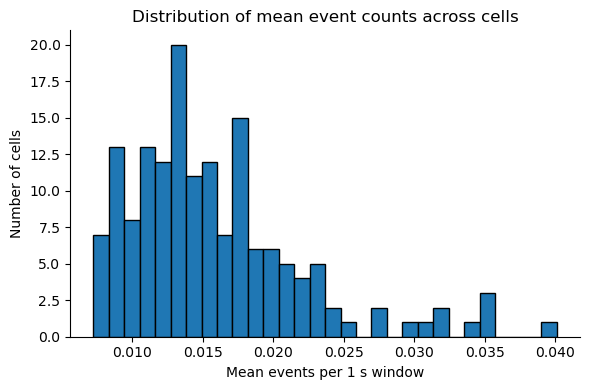

In [5]:
# histogram of firing rate across all cells
import matplotlib.pyplot as plt

mean_events_per_cell = eventsPerSecond_df.mean(axis=0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(mean_events_per_cell, bins=30, edgecolor="black")
ax.set_xlabel("Mean events per 1 s window")
ax.set_ylabel("Number of cells")
ax.set_title("Distribution of mean event counts across cells")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [6]:
# load all 

base_dir = Path("/scratch/jma819/CaliAli_linearTrackData")

paths = [
    base_dir / "m311_analysis/eventsPerSecond_df.csv",
    base_dir / "m326_analysis/eventsPerSecond_df.csv",
    base_dir / "m328_analysis/all_peak_stats_20260518_152949_events_per_second_window20_20260528_233031.csv",
    base_dir / "m752_analysis/all_peak_stats_20260518_211705_events_per_second_window20_20260528_232058.csv",
    base_dir / "m757_analysis/all_peak_stats_20260518_152949_events_per_second_window20_20260528_233137.csv",
    base_dir / "m989_analysis/eventsPerSecond_df.csv",
    base_dir / "m992_analysis/all_peak_stats_20260528_225719_events_per_second_window20_20260529_070109.csv",
    base_dir / "m994_analysis/eventsPerSecond_df.csv",
    base_dir / "m388_analysis/all_peak_stats_20260518_211705_events_per_second_window20_20260529_070021.csv"
]

events_per_second_by_mouse = {}

for path in paths:
    print(path)
    mouse = path.parent.name.replace("_analysis", "")
    df = pd.read_csv(path, index_col=0)
    df.index.name = "window_start_idx"
    events_per_second_by_mouse[mouse] = df

events_per_second_multi_df = pd.concat(
    events_per_second_by_mouse,
    names=["mouse", "window_start_idx"]
)

print(events_per_second_multi_df.shape)
events_per_second_multi_df.head()


/scratch/jma819/CaliAli_linearTrackData/m311_analysis/eventsPerSecond_df.csv
/scratch/jma819/CaliAli_linearTrackData/m326_analysis/eventsPerSecond_df.csv
/scratch/jma819/CaliAli_linearTrackData/m328_analysis/all_peak_stats_20260518_152949_events_per_second_window20_20260528_233031.csv
/scratch/jma819/CaliAli_linearTrackData/m752_analysis/all_peak_stats_20260518_211705_events_per_second_window20_20260528_232058.csv
/scratch/jma819/CaliAli_linearTrackData/m757_analysis/all_peak_stats_20260518_152949_events_per_second_window20_20260528_233137.csv
/scratch/jma819/CaliAli_linearTrackData/m989_analysis/eventsPerSecond_df.csv
/scratch/jma819/CaliAli_linearTrackData/m992_analysis/all_peak_stats_20260528_225719_events_per_second_window20_20260529_070109.csv
/scratch/jma819/CaliAli_linearTrackData/m994_analysis/eventsPerSecond_df.csv
/scratch/jma819/CaliAli_linearTrackData/m388_analysis/all_peak_stats_20260518_211705_events_per_second_window20_20260529_070021.csv
(2055351, 1431)


cell_0  cell_1  cell_2  cell_3  cell_4  cell_5  \
mouse window_start_idx                                                   
m311  0                    1.0     0.0     0.0     0.0     2.0     1.0   
      1                    0.0     0.0     0.0     0.0     0.0     0.0   
      2                    0.0     0.0     0.0     0.0     0.0     0.0   
      3                    0.0     0.0     0.0     0.0     0.0     0.0   
      4                    0.0     0.0     0.0     0.0     0.0     0.0   

                        cell_6  cell_7  cell_8  cell_9  ...  cell_1866  \
mouse window_start_idx                                  ...              
m311  0                    0.0     0.0     0.0     0.0  ...        NaN   
      1                    0.0     0.0     0.0     0.0  ...        NaN   
      2                    0.0     0.0     0.0     0.0  ...        NaN   
      3                    0.0     0.0     0.0     0.0  ...        NaN   
      4                    0.0     0.0     0.0     0.0  ...        NaN   

                        cell_1867  cell_1868  cell_1870  cell_1871  cell_1874  \
mouse window_start_idx                                                          
m311  0                       NaN        NaN        NaN        NaN        NaN   
      1                       NaN        NaN        NaN        NaN        NaN   
      2                       NaN        NaN        NaN        NaN        NaN   
      3                       NaN        NaN        NaN        NaN        NaN   
      4                       NaN        NaN        NaN        NaN        NaN   

                        cell_1875  cell_1876  cell_1877  cell_1878  
mouse window_start_idx                                              
m311  0                       NaN        NaN        NaN        NaN  
      1                       NaN        NaN        NaN        NaN  
      2                       NaN        NaN        NaN        NaN  
      3                       NaN        NaN        NaN        NaN  
      4                       NaN        NaN        NaN        NaN  

[5 rows x 1431 columns]

In [10]:
batch_id = 1
h5_path = base_dir / f"events_per_second_by_mouse_batch{batch_id:03d}.h5"
manifest_csv_path = base_dir / f"events_per_second_by_mouse_batch{batch_id:03d}_manifest.csv"

str_dtype = h5py.string_dtype(encoding="utf-8")
manifest_rows = []

with h5py.File(h5_path, "w") as f:
    records_grp = f.create_group("records")

    for i, path in enumerate(paths, start=1):
        mouse = path.parent.name.replace("_analysis", "")
        print(mouse)
        df = pd.read_csv(path, index_col=0)
        df.index.name = "window_start_idx"

        key = f"r{i:03d}_{mouse}"
        grp = records_grp.create_group(key)

        grp.create_dataset("values", data=df.to_numpy(dtype=np.float32), compression="gzip")
        grp.create_dataset("index", data=df.index.to_numpy(dtype=np.int64), compression="gzip")
        grp.create_dataset("columns", data=np.array(df.columns.astype(str), dtype=object), dtype=str_dtype)

        grp.attrs["record_id"] = i
        grp.attrs["mouse"] = mouse
        grp.attrs["source_path"] = str(path)
        grp.attrs["source_file"] = path.name
        grp.attrs["analysis_dir"] = path.parent.name
        grp.attrs["index_name"] = df.index.name or ""

        manifest_rows.append({
            "record_id": i,
            "h5_key": key,
            "mouse": mouse,
            "source_path": str(path),
            "source_file": path.name,
            "analysis_dir": path.parent.name,
        })

manifest_df = pd.DataFrame(manifest_rows)
manifest_df.to_csv(manifest_csv_path, index=False)

print(h5_path)
print(manifest_csv_path)
manifest_df

/scratch/jma819/CaliAli_linearTrackData/events_per_second_by_mouse_batch001.h5
/scratch/jma819/CaliAli_linearTrackData/events_per_second_by_mouse_batch001_manifest.csv


,record_id,h5_key,mouse,source_path,source_file,analysis_dir
0,1,r001_m311,m311,/scratch/jma819/CaliAli_linearTrackData/m311_a...,eventsPerSecond_df.csv,m311_analysis
1,2,r002_m326,m326,/scratch/jma819/CaliAli_linearTrackData/m326_a...,eventsPerSecond_df.csv,m326_analysis
2,3,r003_m328,m328,/scratch/jma819/CaliAli_linearTrackData/m328_a...,all_peak_stats_20260518_152949_events_per_seco...,m328_analysis
3,4,r004_m752,m752,/scratch/jma819/CaliAli_linearTrackData/m752_a...,all_peak_stats_20260518_211705_events_per_seco...,m752_analysis
4,5,r005_m757,m757,/scratch/jma819/CaliAli_linearTrackData/m757_a...,all_peak_stats_20260518_152949_events_per_seco...,m757_analysis
5,6,r006_m989,m989,/scratch/jma819/CaliAli_linearTrackData/m989_a...,eventsPerSecond_df.csv,m989_analysis
6,7,r007_m992,m992,/scratch/jma819/CaliAli_linearTrackData/m992_a...,all_peak_stats_20260528_225719_events_per_seco...,m992_analysis
7,8,r008_m994,m994,/scratch/jma819/CaliAli_linearTrackData/m994_a...,eventsPerSecond_df.csv,m994_analysis
8,9,r009_m388,m388,/scratch/jma819/CaliAli_linearTrackData/m388_a...,all_peak_stats_20260518_211705_events_per_seco...,m388_analysis


In [11]:
manifest_df = pd.read_csv(manifest_csv_path)
m328_info = manifest_df.loc[manifest_df["mouse"] == "m328"].iloc[0]
with h5py.File(h5_path, "r") as f:
    grp = f["records"][m328_info["h5_key"]]
    m328_df = pd.DataFrame(
        grp["values"][()],
        index=grp["index"][()],
        columns=grp["columns"].asstr()[()],
    )
    m328_df.index.name = grp.attrs["index_name"]
m328_df.head()

,cell_0,cell_1,cell_2,cell_3,cell_5,cell_6,cell_8,cell_9,cell_10,cell_11,...,cell_155,cell_156,cell_157,cell_158,cell_161,cell_162,cell_163,cell_164,cell_165,cell_167
window_start_idx,,,,,,,,,,,,,,,,,,,,,
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
def moving_window_nanmean(x, window_len):
    x = np.asarray(x, dtype=float)
    valid = np.isfinite(x).astype(float)
    x0 = np.where(np.isfinite(x), x, 0.0)

    num = np.convolve(x0, np.ones(window_len, dtype=float), mode="valid")
    den = np.convolve(valid, np.ones(window_len, dtype=float), mode="valid")

    return np.divide(
        num,
        den,
        out=np.full_like(num, np.nan, dtype=float),
        where=den > 0
    )

In [ ]:
base_dir = Path("/scratch/jma819/CaliAli_linearTrackData")
window_len = 20

events_per_second_with_velocity_by_mouse = {}

for mouse in events_per_second_multi_df.index.get_level_values("mouse").unique():
    print(mouse)

    mouse_windows = events_per_second_multi_df.xs(mouse, level="mouse", drop_level=True)
    window_start_idx = mouse_windows.index.to_numpy(dtype=np.int64)

    gcamp_path = base_dir / f"{mouse}_analysis" / "GCAMP_with_velocity.csv"
    velocity = pd.read_csv(
        gcamp_path,
        usecols=["Velocity_spatial_filtered"],
        dtype={"Velocity_spatial_filtered": "float32"},
    )["Velocity_spatial_filtered"].to_numpy()

    print("calculating velocity_window_mean")
    velocity_window_mean = moving_window_nanmean(velocity, window_len)

    if window_start_idx.max() >= len(velocity_window_mean):
        raise ValueError(
            f"{mouse}: window index exceeds available windowed velocity length "
            f"({window_start_idx.max()} vs {len(velocity_window_mean) - 1})"
        )

    velocity_meta = pd.DataFrame(
        {
            "Velocity_spatial_filtered": velocity[window_start_idx],
            "Velocity_spatial_filtered_window_mean": velocity_window_mean[window_start_idx],
        },
        index=mouse_windows.index,
    )
    velocity_meta.index.name = "window_start_idx"

    mouse_with_velocity_df = mouse_windows.join(velocity_meta)

    save_path = (
        base_dir
        / f"{mouse}_analysis"
        / f"eventsPerSecond_with_velocity_window{window_len}.csv"
    )
    print('saving')
    mouse_with_velocity_df.to_csv(save_path, index=True)
    print(f"saved: {save_path}")

    events_per_second_with_velocity_by_mouse[mouse] = mouse_with_velocity_df

In [ ]:
print("optional concatenation")
events_per_second_with_velocity_multi_df = pd.concat(
    events_per_second_with_velocity_by_mouse,
    names=["mouse", "window_start_idx"]
)

print(events_per_second_with_velocity_multi_df.shape)
events_per_second_with_velocity_multi_df.head()

In [ ]:

base_dir = Path("/scratch/jma819/CaliAli_linearTrackData")
window_len = 20

velocity_bins = [(0, 0.5), (0.5, 2), (2, 5), (5, 10), (10, np.inf)]

bin_edges = [b[0] for b in velocity_bins] + [velocity_bins[-1][1]]
bin_labels = [
    f"{lo:g}-{hi:g}" if np.isfinite(hi) else f"{lo:g}+"
    for lo, hi in velocity_bins
]
label_to_bounds = dict(zip(bin_labels, velocity_bins))

mouse_bin_rows = []

for csv_path in sorted(base_dir.glob(f"m*_analysis/eventsPerSecond_with_velocity_window{window_len}.csv")):
    mouse = csv_path.parent.name.replace("_analysis", "")
    print(mouse)

    mouse_df = pd.read_csv(csv_path, index_col=0)

    cell_cols = [c for c in mouse_df.columns if str(c).startswith("cell_")]

    # mean across all cells for each window
    mean_events = mouse_df[cell_cols].mean(axis=1, skipna=True)

    # use the window-matched velocity
    velocity_for_binning = pd.to_numeric(
        mouse_df["Velocity_spatial_filtered_window_mean"],
        errors="coerce"
    )

    print('binning velocity')
    # bin velocity
    velocity_bin = pd.cut(
        velocity_for_binning,
        bins=bin_edges,
        labels=bin_labels,
        right=False,
        include_lowest=True
    )

    tmp = pd.DataFrame({
        "mean_events_per_second_across_cells": mean_events,
        "velocity_for_binning": velocity_for_binning,
        "velocity_bin": velocity_bin,
    })

    summary = (
        tmp
        .dropna(subset=["velocity_bin"])
        .groupby("velocity_bin", observed=False)
        .agg(
            mean_events_per_second=("mean_events_per_second_across_cells", "mean"),
            sem_events_per_second=("mean_events_per_second_across_cells", "sem"),
            n_windows=("mean_events_per_second_across_cells", "size"),
            mean_velocity=("velocity_for_binning", "mean"),
        )
        .reset_index()
    )

    summary["mouse"] = mouse
    summary["speed_bin_low"] = summary["velocity_bin"].map(lambda lbl: label_to_bounds[str(lbl)][0])
    summary["speed_bin_high"] = summary["velocity_bin"].map(lambda lbl: label_to_bounds[str(lbl)][1])

    mouse_bin_rows.append(summary)

mouse_velocity_binned_df = pd.concat(mouse_bin_rows, ignore_index=True)

mouse_velocity_binned_df


